# E-Commerce Customer Segmentation Analysis
**Author:** Pooja Chevli
**Date:** December 2025

### 1. Executive Summary
**Objective:** The business faces a "Leaky Bucket" problem where valuable customers are becoming inactive. This project utilizes **RFM Analysis (Recency, Frequency, Monetary)** and **K-Means Clustering** to segment the customer base and identify "At-Risk" high-value customers for targeted retention campaigns.

**Methodology:**
1.  **Data Ingestion:** Merged 5 months of transaction data (Oct 2019 - Feb 2020).
2.  **RFM Engineering:** Calculated R, F, and M metrics for 110,000+ unique users.
3.  **Clustering:** Applied Log Transformation and StandardScaler before using K-Means (K=4).
4.  **Strategy:** Developed specific retention strategies for 4 distinct segments.

In [51]:
# PROJECT METADATA
"""
-----------------------------------------------------------------------
File: Customer_Segmentation.ipynb
Author: Pooja Chevli
Date: December 2025
Description: E-Commerce RFM analysis and K-Means clustering pipeline.
-----------------------------------------------------------------------
"""

# Import all necessary libraries
import pandas as pd
import numpy as np
import datetime as dt
import gc
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import textwrap

In [49]:
# --- CONFIGURATION: SET WORKING DIRECTORY ---

# This line is commented out to ensure the notebook is reproducible across different machines and for public sharing on GitHub.
# Original: 
# import os
# os.chdir('path_of_current_working_directory') 
# print("Current working directory set to:", os.getcwd())

### 2. Data Ingestion and Cleaning
We aggregate monthly transaction files into a master dataset. Critical cleaning steps include:
* **Filtering:** Keeping only 'purchase' events to focus on revenue-generating behavior.
* **Data Types:** Converting `event_time` to datetime objects for Recency calculation.
* **Sanity Checks:** Removing transactions with non-positive prices (returns/errors).

In [3]:
# Configuration: List of monthly data files to be processed
file_names = [
    '2019-Oct.csv', '2019-Nov.csv', '2019-Dec.csv', 
    '2020-Jan.csv', '2020-Feb.csv']

# Initialization: Empty list to store processed DataFrames
all_df = []

In [4]:
# --- START: FILE MERGING AND FILTERING ---
for file in file_names:
    if os.path.exists(file):
        print(f"Processing {file}...")

        # Load file, setting low_memory=False for type integrity
        temp_df = pd.read_csv(file, low_memory = False)

        # Filter immediately for 'purchase' events to save RAM
        purchase_df = temp_df[temp_df["event_type"] == "purchase"].copy()

        all_df.append(purchase_df)
        print(f" -> Added {len(purchase_df)} rows from {file}")

        # Crucial: Free up memory by deleting the large temporary DataFrame
        del temp_df

    else:
        print(f"Warning: Could not find {file}. Skipping.")

# --- END: FILE MERGING AND FILTERING ---

Processing 2019-Oct.csv...
 -> Added 245624 rows from 2019-Oct.csv
Processing 2019-Nov.csv...
 -> Added 322417 rows from 2019-Nov.csv
Processing 2019-Dec.csv...
 -> Added 213176 rows from 2019-Dec.csv
Processing 2020-Jan.csv...
 -> Added 263797 rows from 2020-Jan.csv
Processing 2020-Feb.csv...
 -> Added 241993 rows from 2020-Feb.csv


In [5]:
# --- File Consolidation and Save ---
if all_df:
    master_df = pd.concat(all_df, ignore_index = True)  # Concatenates list into one DataFrame
    print("--------------------------------------------")
    print(f"Final Master Dataset shape: {master_df.shape}")

    # Saves the final file to disk
    master_df.to_csv('Master_Cosmetics_Purchases.csv', index=False)
    print("Saved it....")

else:
    print("No data found, check paths")

--------------------------------------------
Final Master Dataset shape: (1287007, 9)
Saved it....


In [6]:
# Final Memory Cleanup: Remove the massive list of individual DataFrames
del all_df
import gc
gc.collect() 

print("Memory cleanup complete.")

Memory cleanup complete.


In [7]:
# RELOAD MASTER TRANSACTION DATA

master_df = pd.read_csv("Master_Cosmetics_Purchases.csv", low_memory = False)

In [8]:
## Data Type Conversion (Critical for RFM)

# Check the initial data type for confirmation
print(master_df.dtypes)

# CRITICAL: Convert event_time to datetime object.
# This conversion is mandatory because date subtraction (required for Recency calculation) 
# only works if the column is a datetime type.
master_df["event_time"] = pd.to_datetime(master_df["event_time"])

# Check the new data types
print("\n--- Datatypes after Change ---")
print(master_df.dtypes)

event_time        object
event_type        object
product_id         int64
category_id        int64
category_code     object
brand             object
price            float64
user_id            int64
user_session      object
dtype: object

--- Datatypes after Change ---
event_time       datetime64[ns, UTC]
event_type                    object
product_id                     int64
category_id                    int64
category_code                 object
brand                         object
price                        float64
user_id                        int64
user_session                  object
dtype: object


In [9]:
# Check for missing values (nulls). 
# Ensure we don't have "Ghost Users" (missing user_id).
print("--- Missing Values ---")
print(master_df.isnull().sum())

--- Missing Values ---
event_time             0
event_type             0
product_id             0
category_id            0
category_code    1269793
brand             549693
price                  0
user_id                0
user_session           0
dtype: int64


In [10]:
# Set number format for better human readability (standard float/money format). 
# This is not required for computation but aids in initial data checks
pd.set_option("display.float_format", lambda x: '%.2f' % x)

# Check initial descriptive statistics for the price column
print(master_df[["price"]].describe())

           price
count 1287007.00
mean        4.93
std         8.92
min       -79.37
25%         1.59
50%         3.00
75%         5.40
max       327.78


In [11]:
# CRITICAL FILTERING: Remove non-positive prices. 

# These rows represent returns or data errors that would skew Monetary value.
negative_rows = master_df[master_df["price"] <= 0]
print(f"Rows with Negative/Zero price: {len(negative_rows)}")

# Filter the DataFrame to keep only positive prices
master_df = master_df[master_df["price"] > 0]

Rows with Negative/Zero price: 127


In [12]:
# --- Data Quality Confirmation ---

# Final check to confirm that the price minimum is positive and the final shape is correct.
print("--- New Price Stats ---")
print(master_df[['price']].describe())
print(f"\nNew master_df Shape: {master_df.shape}")

--- New Price Stats ---
           price
count 1286880.00
mean        4.94
std         8.92
min         0.05
25%         1.59
50%         3.00
75%         5.40
max       327.78

New master_df Shape: (1286880, 9)


### 3. RFM Feature Engineering
We transform the raw transaction data into a customer-level dataset using three key metrics:
* **Recency (R):** Days since the last purchase (Lower is better).
* **Frequency (F):** Total number of transactions (Higher is better).
* **Monetary (M):** Total spend amount (Higher is better).

*Note: A snapshot date of `2020-03-01` is used to simulate the analysis occurring immediately after the dataset ends.*

In [13]:
# --- RFM Feature Engineering Setup ---

# Find the date of the latest transaction in the dataset
latest_date = master_df["event_time"].max()

# Define the Snapshot Date (the reference point for Recency)
# We set it to one day after the last transaction to ensure Recency scores are positive (Recency >= 1)
snapshot_date = latest_date + dt.timedelta(days = 1)

print(f"Latest trasaction date: {latest_date}")
print(f"Snapshot date: {snapshot_date}")

Latest trasaction date: 2020-02-29 23:54:44+00:00
Snapshot date: 2020-03-01 23:54:44+00:00


In [14]:
# --- RFM Aggregation and Cleanup ---

# Group the transaction data by 'user_id' and apply the R, F, M calculations simultaneously.
rfm_df = master_df.groupby("user_id").agg(
    
    # Recency: Calculate the difference in days between the snapshot date and the user's latest purchase.
    Recency = ("event_time", lambda x: (snapshot_date - x.max()).days),

    # Frequency: Count the total number of transactions (user_session is the proxy for one transaction).
    Frequency = ("user_session", "count"),

    # Monetary: Sum the total price spent by the customer.
    Monetary = ("price", "sum")
).reset_index() # .reset_index() converts the user_id (the index) back into a standard column.

print("\n--- RFM DataFrame Head ---")
print(rfm_df.head())
print(f"\nRFM DataFrame Shape: {rfm_df.shape}")

# CRITICAL MEMORY CLEANUP: Delete the huge master_df as it's no longer needed.
# Deleting this frees up significant RAM, preventing potential kernel crashes 
# during memory-intensive steps like K-Means clustering and plotting.

del master_df
gc.collect() 
print("master_df successfully cleared from memory.")


--- RFM DataFrame Head ---
    user_id  Recency  Frequency  Monetary
0   9794320       97          4     12.68
1  10079204      116          2     25.81
2  10280338       11         86    177.83
3  12055855       72          4     16.54
4  12936739       44          2     29.89

RFM DataFrame Shape: (110518, 4)
master_df successfully cleared from memory.


In [15]:
print(rfm_df.describe())

           user_id   Recency  Frequency  Monetary
count    110518.00 110518.00  110518.00 110518.00
mean  528608019.30     70.72      11.64     57.47
std    87547392.97     43.92      18.27     88.64
min     9794320.00      1.00       1.00      0.13
25%   495094295.25     32.00       3.00     16.27
50%   559850017.00     71.00       6.00     33.22
75%   586252663.75    106.00      13.00     61.58
max   622073202.00    152.00     715.00   3785.03


In [16]:
# --- PRODUCT CATEGORY PROFILING FOR THRESHOLD JUSTIFICATION ---

# Reloading master_df to identify product categories. The lifecycle of the dominant category will then be 
# used to determine the justified Inactivity Threshold.

# RELOAD MASTER TRANSACTION DATA
try: 
    # Reload the original transaction data from the CSV file.
    master_df = pd. read_csv("Master_Cosmetics_Purchases.csv")

    # Convert the date column to the datetime format for accurate analysis.
    master_df['event_time'] = pd.to_datetime(master_df["event_time"])
    
    print(f"Master Data Reloaded Successfully. Shape: {master_df.shape}")

except FileNotFoundError:
    print("ERROR: master_data.csv not found. Check file name and path.")

# PROFILE PRODUCT CATEGORIES BY TRANSACTION VOLUME

# Group the master data by category_code to aggregate sales metrics and determine 
# the percentage reliance on the dominant product line.

# Calculate the total number of transactions in the entire dataset for percentage calculation.
TOTAL_TRANSACTIONS = master_df.shape[0]

# Group the master data by the category_code.
ctg_profile = master_df.groupby("category_code").agg(
    
    # Total_Transactions: Count of transactions per category (proxy for popularity)
    Total_Transactions = ("user_session", "count"),
    
    # Total_Revenue: Sum the monetary value generated by each category
    Total_Revenue = ("price", "sum")
).reset_index()

# Add the Contribution Percentage column
ctg_profile['Contribution_Percent'] = (ctg_profile['Total_Transactions'] / TOTAL_TRANSACTIONS) * 100

# Sort the results in descending order by transaction count.
ctg_profile_sorted = ctg_profile.sort_values(by = "Total_Transactions", ascending = False)

print("\n--- Top 5 Product Categories by Transaction Volume ---")
print(ctg_profile_sorted.head())

Master Data Reloaded Successfully. Shape: (1287007, 9)

--- Top 5 Product Categories by Transaction Volume ---
                    category_code  Total_Transactions  Total_Revenue  \
10            stationery.cartrige                6327       14107.07   
2                   apparel.glove                4977       34340.60   
4   appliances.environment.vacuum                4000      138623.97   
7         furniture.bathroom.bath                1162       18710.24   
8   furniture.living_room.cabinet                 293       40746.98   

    Contribution_Percent  
10                  0.49  
2                   0.39  
4                   0.31  
7                   0.09  
8                   0.02  


### 4. Statistical Transformation
K-Means clustering assumes that variables are symmetric (not skewed) and have the same variance.
1.  **Log Transformation:** Applied `np.log(x+1)` to handle the heavy right-skew in Monetary and Frequency data.
2.  **Standardization:** Used `StandardScaler` to normalize variables so that Money (e.g., \$200) doesn't dominate Frequency (e.g., 5).

In [17]:
# --- LOG TRANSFORMATION FOR CLUSTERING ---

# Create a new DataFrame for the transformed data.
rfm_log = rfm_df.copy()

# Apply the Log(x+1) transformation to R, F, and M variables.
rfm_log["Recency_log"] = np.log(rfm_log["Recency"] + 1)
rfm_log["Frequency_log"] = np.log(rfm_log["Frequency"] + 1)
rfm_log["Monetary_log"] = np.log(rfm_log["Monetary"] + 1)

print("\n --- RFM Log Trasformed Head ---")
print(rfm_log[["user_id", "Recency_log", "Frequency_log", "Monetary_log"]].head())

# Display descriptive stats on the log-transformed data
print("\n--- Descriptive Stats after the Transformation ---")
print(rfm_log[['Recency_log', 'Frequency_log', 'Monetary_log']].describe())


 --- RFM Log Trasformed Head ---
    user_id  Recency_log  Frequency_log  Monetary_log
0   9794320         4.58           1.61          2.62
1  10079204         4.76           1.10          3.29
2  10280338         2.48           4.47          5.19
3  12055855         4.29           1.61          2.86
4  12936739         3.81           1.10          3.43

--- Descriptive Stats after the Transformation ---
       Recency_log  Frequency_log  Monetary_log
count    110518.00      110518.00     110518.00
mean          3.96           2.05          3.56
std           0.94           0.91          0.95
min           0.69           0.69          0.12
25%           3.50           1.39          2.85
50%           4.28           1.95          3.53
75%           4.67           2.64          4.14
max           5.03           6.57          8.24


In [18]:
rfm_df.describe()

,user_id,Recency,Frequency,Monetary
count,110518.00,110518.00,110518.00,110518.00
mean,528608019.30,70.72,11.64,57.47
std,87547392.97,43.92,18.27,88.64
min,9794320.00,1.00,1.00,0.13
25%,495094295.25,32.00,3.00,16.27
50%,559850017.00,71.00,6.00,33.22
75%,586252663.75,106.00,13.00,61.58
max,622073202.00,152.00,715.00,3785.03


In [19]:
# --- STANDARDIZATION (SCALING) ---

# The range of Monetary_log is greater then the range of R and F. 
# Therefor we need to standardize them

# Select the log-transformed features
X = rfm_log[['Recency_log', 'Frequency_log', 'Monetary_log']]

# Initialize and Fit/Transform the Scaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\n--- Scaled Data Head (Mean=0, Std=1) ---")

# Convert the NumPy array back to a DataFrame for clean output
X_scaled_df = pd.DataFrame(X_scaled, columns = X.columns)
print(X_scaled_df.head())


--- Scaled Data Head (Mean=0, Std=1) ---
   Recency_log  Frequency_log  Monetary_log
0         0.66          -0.48         -1.00
1         0.85          -1.04         -0.29
2        -1.57           2.64          1.71
3         0.35          -0.48         -0.73
4        -0.17          -1.04         -0.14


### 5. Model Selection (K-Means)
To determine the optimal number of segments (K), we utilize two methods:
* **Elbow Method:** Indicates an inflection point around K=3 or K=4.
* **Silhouette Score:** While lower K values (K=2) mathematically maximized the silhouette score, they failed to provide granular business distinctions.

*Decision:* We selected **K=4** because it provided the most actionable business segmentation (separating "Champions" from "Loyal" and "At-Risk" customers), which K=3 merged into too broad of a group.

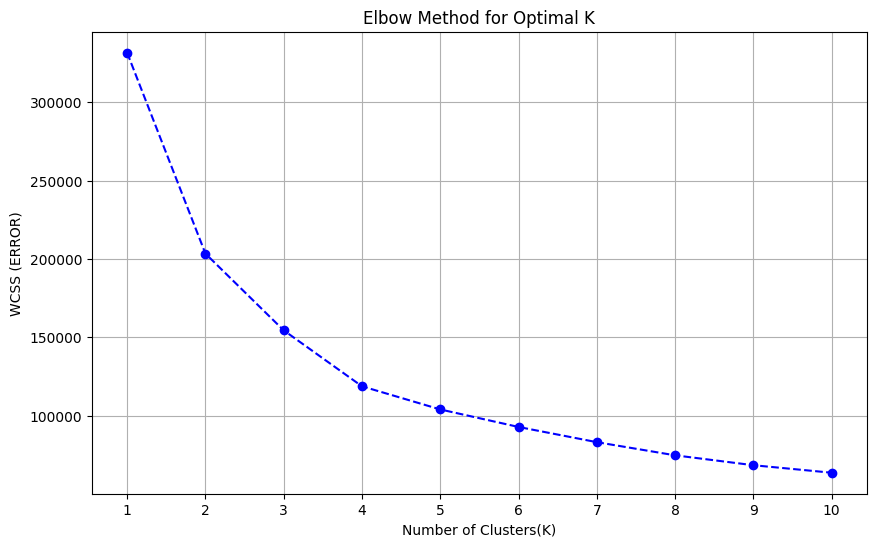

In [20]:
# --- DETERMINE OPTIMAL K (ELBOW METHOD) ---

# Drop any row from the rfm_log DataFrame that contains a NaN value
rfm_log.dropna(inplace=True)

# Isolate the log-transformed features for clustering
X = X_scaled

# Calculate WCSS (Within-Cluster Sum of Squares) for K=1 to K=10
WCSS = []
range_k = range(1, 11)

for k in range_k:
    # Initialize KMeans with k clusters
    # random_state=42 ensures the results are reproducible every time you run it.
    kmeans = KMeans(n_clusters = k, init = 'k-means++', random_state = 42, n_init = 10)

    # Fit the algorithm to the data
    kmeans.fit(X)

    # Append the Inertia (WCSS) to the list
    WCSS.append(kmeans.inertia_)

# 3. Plot the Elbow Curve
plt.figure(figsize = (10,6))

plt.plot(range_k, WCSS, marker = "o", linestyle = "--", color = "b")

plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters(K)")
plt.ylabel("WCSS (ERROR)")
plt.xticks(range_k)   
plt.grid(True)
plt.show()

In [21]:
# --- CALCULATE SILHOUETTE SCORE ---

range_k = [3, 4, 5]

print("--- SilhouettecScores (Higher is Better) --- ")

# --- PERFORMANCE WARNING ---
# The Silhouette Score calculation is computationally expensive for this dataset size (100k+ rows).
# It is commented out to allow for faster notebook review.
# The selection of K=4 was ultimately validated by business domain logic (see Methodology section in Report).

# for k in range_k:
#     # Initialize KMeans
#     kmeans = KMeans(n_clusters = k, init = 'k-means++', random_state = 42, n_init = 10)

#     # Fit the model and predict labels
#     cluster_labels = kmeans.fit_predict(X)

#     # Calculate the score
#     # This computes the mean Silhouette Coefficient of all samples
#     silhouette_avg = silhouette_score(X, cluster_labels)

#     print(f"For K = {k}, the SIlhouette Scre is: {silhouette_avg:.4f}")

--- SilhouettecScores (Higher is Better) --- 
For K = 3, the SIlhouette Scre is: 0.3562
For K = 4, the SIlhouette Scre is: 0.3271
For K = 5, the SIlhouette Scre is: 0.2745


In [22]:
# --- FINAL K-MEANS MODEL & LABEL ASSIGNMENT ---

# Run the Final K-Means Model with K=4
kmeans = KMeans(n_clusters = 4, init = 'k-means++', random_state = 42, n_init = 10)
kmeans.fit(X_scaled)

# Assign labels to rfm_log (The "Clean" dataset)
rfm_log["Cluster_Label"] = kmeans.labels_

# Create the Final DataFrame by merging
rfm_final = rfm_df.merge(rfm_log[["Cluster_Label"]], left_index = True, right_index = True, how = "inner")

# View the Result
print("--- Final CLustered Data ---")
print(rfm_final.head())
print("\n--- Cluster Counts ---")
print(rfm_final["Cluster_Label"].value_counts())

--- Final CLustered Data ---
    user_id  Recency  Frequency  Monetary  Cluster_Label
0   9794320       97          4     12.68              0
1  10079204      116          2     25.81              0
2  10280338       11         86    177.83              1
3  12055855       72          4     16.54              0
4  12936739       44          2     29.89              0

--- Cluster Counts ---
Cluster_Label
0    41809
2    37566
3    17260
1    13883
Name: count, dtype: int64


In [28]:
# --- CLUSTER PROFILING ---

# Calculate the mean (average) R, F, and M for each cluster label
segment_profile = rfm_final.groupby("Cluster_Label")[["Recency","Frequency","Monetary"]].mean().reset_index()

# Rename the columns for clarity (e.g., mean Recency)
segment_profile.columns = ["Cluster_Label","Recency_Mean","Frequency_Mean","Monetary_Mean"]

# Print the profile table sorted by Money (so we see the best customers first)
print("--- Segment Profile (Mean R, F, M)")
print(segment_profile.sort_values(by = "Monetary_Mean", ascending = False))

--- Segment Profile (Mean R, F, M)
   Cluster_Label  Recency_Mean  Frequency_Mean  Monetary_Mean
1              1         37.88           44.04         205.09
2              2         88.80           11.67          57.38
3              3         14.30            6.23          33.79
0              0         88.68            3.10          18.32


### 6. Segment Interpretation
Based on the cluster centers, we have named the four segments:
1.  **Champions / VIPs:** High Spend, High Frequency, Recent.
2.  **New Customers:** Recent purchase, Low Frequency.
3.  **At-Risk (High Value):** High past Spend, but haven't visited recently.
4.  **Hibernating:** Low Spend, Long time since last visit.

In [29]:
# --- FINAL SEGMENT MAPPING (Using your names) ---

# Define the mapping based on your final interpretation
segment_map = {
    1: "Champions / VIPs",
    2: "At-Risk (High Value)",
    0: "Hibernating (Low Value)",
    3: "New Customers"
}

# Apply the mapping to create the final 'Segment' column
rfm_final["Segment"] = rfm_final["Cluster_Label"].map(segment_map)

# Check the final count and names
print("--- Final Segment Distribution by Strategic Name ---")
print(rfm_final["Segment"].value_counts())

--- Final Segment Distribution by Strategic Name ---
Segment
Hibernating (Low Value)    41809
At-Risk (High Value)       37566
New Customers              17260
Champions / VIPs           13883
Name: count, dtype: int64


### 7. Visualization and Insights
Visualizing the size and profile of each segment to drive strategy.

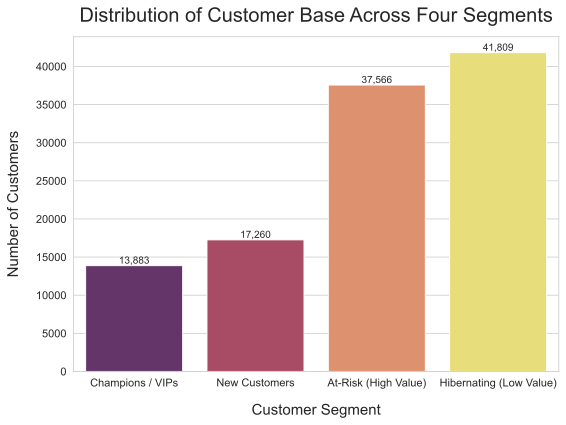

In [30]:
# --- VISUALIZATION - SEGMENT SIZE BAR CHART ---

# Command to ensure vector-quality inline rendering (For good quality visuals)
%config InlineBackend.figure_format = 'svg'

# Defined a cohesive palette for the plots and graphs ahead
custom_colors = ["#6A2C70", "#B83B5E", "#F08A5D", "#F9ED69"]
chosen_palette = sns.color_palette(custom_colors)

#Define Strategic Order (Darkest Color = First Item in List)
strategic_order = ['Champions / VIPs', 'New Customers', 'At-Risk (High Value)', 'Hibernating (Low Value)']

# Set the plot style
sns.set_style("whitegrid")
plt.figure(figsize = (8, 6))

# Create the countplot, ordering bars by size (largest to smallest)
ax = sns.countplot(
    data = rfm_final,
    x = "Segment",
    hue = "Segment",
    order = strategic_order,
    hue_order = strategic_order,
    palette = chosen_palette,
    legend = False
)

plt.title("Distribution of Customer Base Across Four Segments", fontsize = 20, pad = 15)
plt.xlabel("Customer Segment", fontsize = 15, labelpad = 15)   # Pushes label down
plt.ylabel("Number of Customers", fontsize = 15, labelpad = 15)
plt.xticks(fontsize = 11)
plt.yticks(fontsize = 11)
# plt.xticks(rotation = 45, ha = "right")

# Add the counts on top of the bars
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}')   # To format with commas (e.g., 12,345)

plt.tight_layout()
plt.savefig('segment_distribution_bar_chart.png', dpi=300)
plt.show()

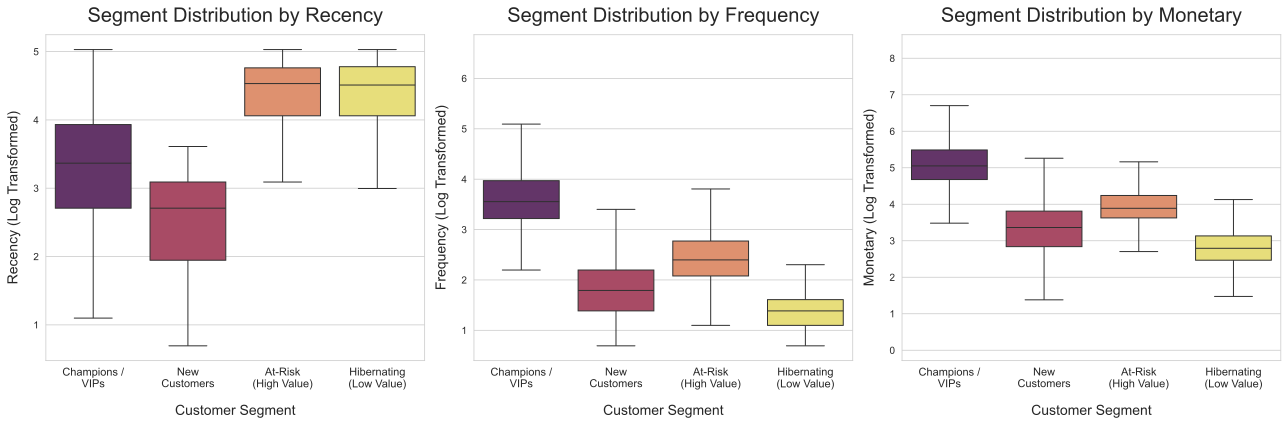

In [45]:
# --- VISUALIZATION - R, F, M BOX PLOTS ---

metrics = ["Recency_log", "Frequency_log", "Monetary_log"]
rfm_log = rfm_log.merge(rfm_final[['user_id', 'Segment']], on='user_id')

# Define the wrapper function for clean X-axis labels
def wrap_labels(labels, max_chars):
    wrapper = textwrap.TextWrapper(width = max_chars, break_long_words = False)
    return ["\n".join(wrapper.wrap(label)) for label in labels]

# Set up the figure with 1 row and 3 columns for the three plots
plt.figure(figsize=(18, 6))
wrapped_segment_labels = wrap_labels(strategic_order, 12)

# Loop through each metric and create a box plot
for i, metric in enumerate(metrics):
    plt.subplot(1, 3, i + 1)

    sns.boxplot(
        x = "Segment",
        y = metric,
        hue = "Segment",
        data = rfm_log,
        order = strategic_order,
        hue_order = strategic_order,
        palette = chosen_palette,
        legend = False,
        fliersize = 0
    )

    # Apply the wrapped labels to the X-axis
    plt.gca().set_xticks(np.arange(len(strategic_order)))
    plt.gca().set_xticklabels(wrapped_segment_labels, ha = "center", fontsize = 11)

    title_name = metric.replace("_log", "")
    plt.title(f"Segment Distribution by {title_name}", fontsize = 20, pad = 13)
    plt.xlabel("Customer Segment", fontsize = 14, labelpad = 15)
    plt.ylabel(f"{title_name} (Log Transformed)", fontsize = 14, labelpad = 13)

plt.tight_layout() # Ensures no overlap between the three subplots
plt.savefig('rfm_segment_profiles.png', dpi=300)
plt.show()
    

### 8. Strategic Recommendations

The analysis yielded four actionable segments. The following table prioritizes the marketing budget and outlines a specific strategy for maximizing customer Lifetime Value (LTV) across the base.

In [47]:
# --- FINAL STRATEGIC RECOMMENDATIONS TABLE ---

recommendations = {
    'Segment': ['1. Champions / VIPs', '2. New Customers', '3. At-Risk (High Value)', '4. Hibernating (Low Value)'],
    'Goal (Why)': ['Retention & Loyalty (Lock in LTV)', 'Frequency Conversion (Drive 2nd Purchase)', 'Immediate Recency Rescue (Prevent Churn)', 'Cost Avoidance (Triage & De-marketing)'],
    'Strategy (How)': ['Surprise & Delight (Non-monetary rewards)', 'Onboarding & Cross-Sell (Clear incentive)', 'Aggressive Personalized Win-Back', 'Last-Chance Test (Minimal Spend)'],
    'Key Tactics': [
        'Exclusive access, free premium service, no discounts.', 
        'Time-limited welcome series coupon (e.g., 10% off).', 
        'High-value discount (20-30% off) targeting past favorite items.', 
        'Single, low-cost offer. If no response in 90 days, stop marketing.'
    ]
}

df_recommendations = pd.DataFrame(recommendations)
df_recommendations.set_index('Segment', inplace=True)

# Display the final output
print("Final Strategic Recommendations:")
df_recommendations.style.set_properties(**{'white-space': 'normal', 'text-align': 'left'}, subset=['Key Tactics'])

Final Strategic Recommendations:


,Goal (Why),Strategy (How),Key Tactics
Segment,,,
1. Champions / VIPs,Retention & Loyalty (Lock in LTV),Surprise & Delight (Non-monetary rewards),"Exclusive access, free premium service, no discounts."
2. New Customers,Frequency Conversion (Drive 2nd Purchase),Onboarding & Cross-Sell (Clear incentive),"Time-limited welcome series coupon (e.g., 10% off)."
3. At-Risk (High Value),Immediate Recency Rescue (Prevent Churn),Aggressive Personalized Win-Back,High-value discount (20-30% off) targeting past favorite items.
4. Hibernating (Low Value),Cost Avoidance (Triage & De-marketing),Last-Chance Test (Minimal Spend),"Single, low-cost offer. If no response in 90 days, stop marketing."
